In [1]:
import socnavgym
import gymnasium as gym
from socnavgym.wrappers import DiscreteActions
from rl.QLearning import *
from tqdm.auto import trange
import imageio

In [2]:

env = gym.make("SocNavGym-v1", config="./environment_configs/exp1_no_sngnn.yaml") 
env = DiscreteActions(env)

SEED = 9
EPISODES = 5000

/home/adonis/Documents/Thesis/socnavgym/SocNavGym/socnavgym/envs/utils/sngnnv2/socnav_V2_API.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.GNNmodel.load_state_di

In [3]:
agent = QL(
        action_size=7,
        learning_rate=0.1,
        gamma=0.99, epsilon=0.05
    )

In [ ]:
obs, _ = env.reset(seed=SEED)
frames = []
for i in range(600):
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    if terminated or truncated:
        break#env.reset(seed=SEED)

rewards = []
length = []
env.close()

# save video
imageio.mimsave("videos/video_no_prm.gif", frames, fps=20)
#for episode in trange(EPISODES):
#    obs = env.reset(seed=SEED)
#    episodes_length, episodes_rewards = agent.act(env, obs)
#    length.append(episodes_length)
#    rewards.append(episodes_rewards)

ValueError: need at least one array to stack

In [ ]:
def rolling_avg(x, w=50):
        pad_width = w // 2
        x_padded = np.pad(x, (pad_width, w - 1 - pad_width), mode='edge')
        return np.convolve(x_padded, np.ones(w) / w, mode='valid')

length_rolling = rolling_avg(length)
rewards_rolling = rolling_avg(rewards)

ValueError: can't extend empty axis 0 using modes other than 'constant' or 'empty'

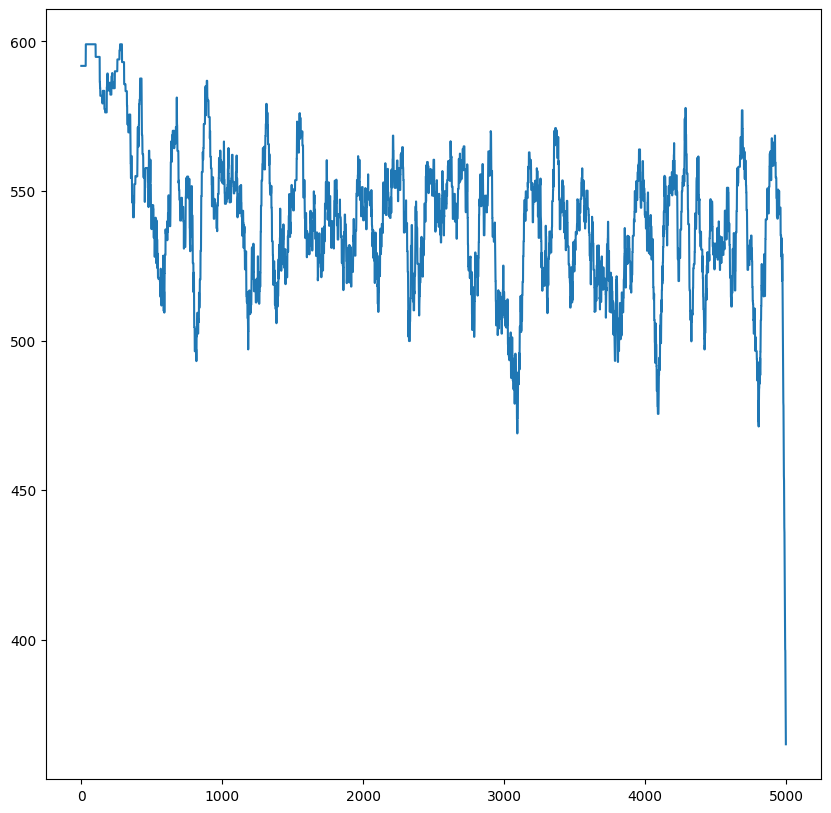

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(1, 1, 1)
ax.plot(length_rolling)

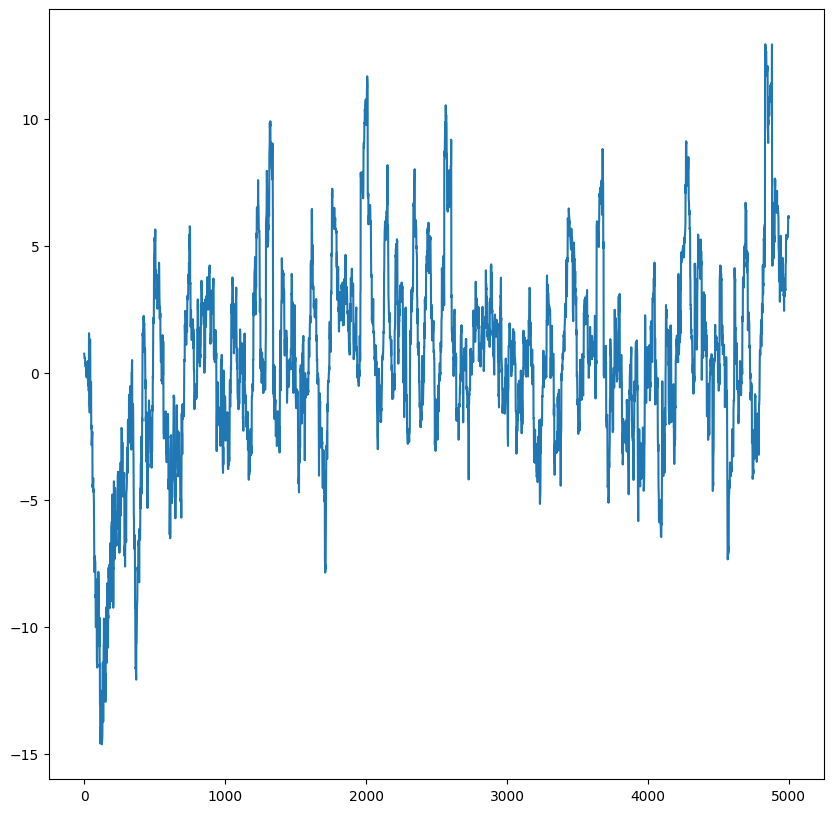

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(1, 1, 1)
ax.plot(rewards_rolling)